In [37]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer

texts = ['먹고 싶은 사과', '먹고 싶은 바나나', '길고 노란 바나나 바나나', '저는 과일이 좋아요']

tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
print(tokenizer.word_index)
# 인덱스는 1부터 시작. 각 단어에 인덱스를 부여한다.

# count 모드: 각 행은 문서(문장), 각 열은 단어로, 문장에 대한 단어의 등장수를 표시.
# 단, 인덱스가 1부터 시작하기 때문에 각 행의 0번 열은 모두 0으로 고정됨. 
print(tokenizer.texts_to_matrix(texts, mode='count'))

# binary 모드: 각 행은 문서(문장), 각 열은 단어로, 문장에 대한 단어의 등장 여부를 0 또는 1로 표시.
# 단, 인덱스가 1부터 시작하기 때문에 각 행의 0번 열은 모두 0으로 고정됨. 
print(tokenizer.texts_to_matrix(texts, mode='binary'))

# tfidf 모드(TF-IDF): 빈도(TF) 뿐 아니라 희귀성(IDF)를 동시 고려
#                     특정 문서 내에서 자주 나오지만 전체 문서군에선 드문 단어에 높은 가중치
#                     a, the 같은 단어의 영향력을 낮추고 주제를 표현하는 핵심 단어를 더 잘 잡음.

# freq 모드: 단어가 차지하는 상대적 비율을 표시. 해당 단어의 등장 횟수 / 문서 내 전체 단어 수

{'바나나': 1, '먹고': 2, '싶은': 3, '사과': 4, '길고': 5, '노란': 6, '저는': 7, '과일이': 8, '좋아요': 9}
[[0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]]
[[0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 1.]]


In [17]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
# 사이킷런의 기본 제공 데이터.
# 20개의 다른 주제를 가진 18.846개의 뉴스 그룹 이메일 데이터 제공

import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical

newsdata = fetch_20newsgroups(subset='train')
# subset = 'train' | 'test' | 'all' : 훈련 데이터/ 테스트 데이터/ 전체 다운로드
print(newsdata.keys())

print(f'훈련용 샘플의 개수 : {len(newsdata.data)}')
print(f"총 주제의 개수 : {len(newsdata.target_names)}")
print(newsdata.target_names)

print(f"첫번째 샘플의 레이블 : {newsdata.target[0]}")
print(f"7번 레이블이 의미하는 주제 : {newsdata.target_names[7]}")

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])
훈련용 샘플의 개수 : 11314
총 주제의 개수 : 20
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
첫번째 샘플의 레이블 : 7
7번 레이블이 의미하는 주제 : rec.autos


In [18]:
print(newsdata.data[0]) # 첫번째 샘플 출력

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [19]:
data = pd.DataFrame(newsdata.data, columns=['email'])
data['target'] = pd.Series(newsdata.target)
data.head()

,email,target
0,From: lerxst@wam.umd.edu (where's my thing)\nS...,7
1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,4
2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,4
3,From: jgreen@amber (Joe Green)\nSubject: Re: W...,1
4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...,14


In [20]:
data.info

<bound method DataFrame.info of                                                    email  target
0      From: lerxst@wam.umd.edu (where's my thing)\nS...       7
1      From: guykuo@carson.u.washington.edu (Guy Kuo)...       4
2      From: twillis@ec.ecn.purdue.edu (Thomas E Will...       4
3      From: jgreen@amber (Joe Green)\nSubject: Re: W...       1
4      From: jcm@head-cfa.harvard.edu (Jonathan McDow...      14
...                                                  ...     ...
11309  From: jim.zisfein@factory.com (Jim Zisfein) \n...      13
11310  From: ebodin@pearl.tufts.edu\nSubject: Screen ...       4
11311  From: westes@netcom.com (Will Estes)\nSubject:...       3
11312  From: steve@hcrlgw (Steven Collins)\nSubject: ...       1
11313  From: gunning@cco.caltech.edu (Kevin J. Gunnin...       8

[11314 rows x 2 columns]>

In [21]:
data.isnull().values.any() # null값이 있는지 체크

False

In [22]:
print(f"중복을 제외한 샘플의 수 : {data['email'].nunique()}")
print(f"중복을 제외한 주제의 수 : {data['target'].nunique()}")

중복을 제외한 샘플의 수 : 11314
중복을 제외한 주제의 수 : 20


<Axes: xlabel='target'>

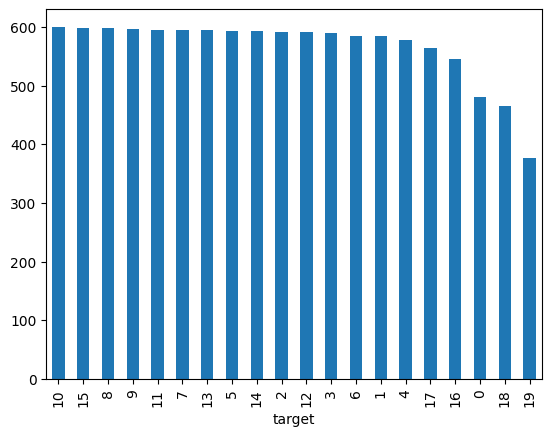

In [23]:
data['target'].value_counts().plot(kind='bar')

In [24]:
data.groupby('target').size().reset_index(name='count')

,target,count
0,0,480
1,1,584
2,2,591
3,3,590
4,4,578
5,5,593
6,6,585
7,7,594
8,8,598
9,9,597


In [31]:
newsdata_test = fetch_20newsgroups(subset='test', shuffle=True)

train_email = data['email']
train_label = data['target']
test_email = newsdata_test.data
test_label = newsdata_test.target

vocab_size = 10000
num_classes = 20

def prepare_data(train_data, test_data, mode): # 전처리 함수
    tokenizer = Tokenizer(num_words = vocab_size)
    tokenizer.fit_on_texts(train_data)
    X_train = tokenizer.texts_to_matrix(train_data, mode=mode) # 샘플 수 x vocab_size 크기의 행렬 생성
    X_test = tokenizer.texts_to_matrix(test_data, mode=mode) # 샘플 수 x vocab_sizse 크기의 행렬 생성
    return X_train, X_test, tokenizer.index_word


X_train, X_test, index_to_word = prepare_data(train_email, test_email, 'binary') # binary 모드: 등장 여부 0/1
y_train = to_categorical(train_label, num_classes)
y_test = to_categorical(test_label, num_classes) # 원-핫 인코딩

print(f"훈련 샘플 본문의 크기 : {X_train.shape}")
print(f"훈련 샘플 레이블의 크기 : {y_train.shape}")
print(f"테스트 샘플 본문의 크기 : {X_test.shape}")
print(f"테스트 샘플 레이블의 크기 : {y_test.shape}")

훈련 샘플 본문의 크기 : (11314, 10000)
훈련 샘플 레이블의 크기 : (11314, 20)
테스트 샘플 본문의 크기 : (7532, 10000)
테스트 샘플 레이블의 크기 : (7532, 20)


In [32]:
print(f"빈도수 상위 1번 단어 : {index_to_word[1]}")
print(f"빈도수 상위 9999번 단어 : {index_to_word[9999]}")

빈도수 상위 1번 단어 : the
빈도수 상위 9999번 단어 : mic


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def fit_and_evaluate(X_train, y_train, X_test, y_test):
    model = Sequential()
    model.add(Dense(256, input_shape=(vocab_size, ), activation="relu"))
    model.add(Dropout(0.5))
    # Dropout: 과적합 방지(0.5 -> 무작위로 50%의 뉴런을 끈다.)
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    model.fit(X_train, y_train, batch_size=128, epochs=5, verbose=1, validation_split=0.1)
    score = model.evaluate(X_test, y_test, batch_size=128, verbose=0)
    # verbose = 0 : 학습과정을 아무것도 출력하지 않음
    # verbose = 1 : 학습과정을 막대바와 함께 상세히 보여줌
    # verbose = 2 : 학습과정을 에포크 당 결과만 한줄씩 출력함
    return score[1]

modes = ["binary", "count", "tfidf", "freq"]

for mode in modes:
    X_train, X_test, _ = prepare_data(train_email, test_email, mode)
    score = fit_and_evaluate(X_train, y_train, X_test, y_test)
    print(mode + "모드의 테스트 정확도:", score)

Epoch 1/5
80/80 [==============================] - 2s 20ms/step - loss: 2.2718 - accuracy: 0.3363 - val_loss: 0.9415 - val_accuracy: 0.8392
Epoch 2/5
80/80 [==============================] - 1s 18ms/step - loss: 0.8809 - accuracy: 0.7512 - val_loss: 0.4507 - val_accuracy: 0.8896
Epoch 3/5
80/80 [==============================] - 1s 17ms/step - loss: 0.4376 - accuracy: 0.8862 - val_loss: 0.3526 - val_accuracy: 0.9002
Epoch 4/5
80/80 [==============================] - 1s 17ms/step - loss: 0.2538 - accuracy: 0.9350 - val_loss: 0.3186 - val_accuracy: 0.9072
Epoch 5/5
80/80 [==============================] - 1s 17ms/step - loss: 0.1769 - accuracy: 0.9583 - val_loss: 0.3057 - val_accuracy: 0.9152
binary모드의 테스트 정확도: 0.8339086771011353
Epoch 1/5
80/80 [==============================] - 2s 17ms/step - loss: 2.7895 - accuracy: 0.2407 - val_loss: 1.6829 - val_accuracy: 0.7429
Epoch 2/5
80/80 [==============================] - 1s 16ms/step - loss: 1.4915 - accuracy: 0.6207 - val_loss: 0.7547 - val